# 19 - Daughter hierarchy length `l_max_ncdm` for warm daughters

Notebook 16 found that `l_max_ncdm = 17`, the CLASS default, is too short for a warm daughter at large
f̃ (−0.6% in σ8_cb at 10¹² GeV, f̃ = 0.5, at any grid). The fixed-mass chains all run at 17 with the full
hierarchy evolved to today. Does it matter?

1. Truncation error: Δχ² of `l_max_ncdm` = 17, 25, 35, 50 against 70 on a (mass, f̃) grid over the warm
   masses, with 10¹⁴ GeV as a cold control; 70 is checked against 100.
2. Against the chains: the error at each chain's 95% and 99% f̃, and the f̃ above which each l_max exceeds
   Δχ² = 0.1.
3. Where in ℓ and k the error sits.
4. Whether it is separate from the momentum-grid error.

`l_max_ncdm` applies to all ncdm species, so it also lengthens the neutrino hierarchy; an f̃ = 10⁻⁶ row
isolates that part.

**Result.**
- Every run at 17, including f̃ = 10⁻⁶, carries Δχ² ≈ 9·10⁻⁴: the neutrino hierarchy, present in every
  default CLASS run.
- Above that floor the daughter's error grows with f̃ and falls steeply with mass: a smooth suppression
  of P_cb above k ≈ 0.01–0.1/Mpc, and so of C_ℓ^φφ and the lensed TT peaks. At 17: 10¹¹ GeV, Δχ² 0.03 /
  0.8 / 2.6 / 8.6 at f̃ = 0.1 / 0.3 / 0.5 / 0.9 (σ8_cb −0.2% to −2.9%); 10¹² GeV, above 0.1 from f̃ ≈ 0.4;
  from 10¹²·⁵ GeV up, below 0.1 everywhere.
- 70 is good to Δχ² ≤ 0.02 against 100. Relative cost 1, 1.35, 1.7, 2.3, 3.1 for 17, 25, 35, 50, 70.
  35 keeps Δχ² ≤ 0.1 except at 10¹¹ GeV, f̃ ≳ 0.3; 50 keeps it ≤ 0.07 everywhere.
- At 10¹² GeV the hierarchy and grid errors are independent and add; at 10¹¹ GeV, f̃ = 0.5 they
  interact, and the grid error is the larger one.
- The chains are unaffected: at their 99% f̃ (current chains, 10¹¹–10¹⁴ GeV) Δχ² is 0.9–1.4·10⁻³, the
  neutrino floor. At 17 the error exceeds 0.1 on 85% / 70% / 62% of the flat f̃ ∈ [0, 0.999] training box
  at 10¹¹ / 10^11.5 / 10¹² GeV, far from the posteriors; it matters for work at large f̃ there (profile
  likelihoods, P(k) probes), which should use `l_max_ncdm` 35–50.

Settings of the 10¹⁴ GeV chain of 2026-10-07 (κ = 12.1, a_t = 0.133, strategy 5, s = 0.25, DE sink on,
50 bins/decade; now in `chains/fixed_masses/_OLD/k12.1a0.133`) with its ΛCDM best fit and fixed
ω_dm,tot. Δχ²: `accdm_nb.compare`, tolerance 0.1. Cached in `19_cache.pkl` (~15 min on 8 workers).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import (ELL, KK, RunCache, chains_dir, chi2_parts, compare, load_chain, mass_dirs, ok, show,
                      status, wquantile, plot_style)

plot_style()

SETTINGS = {'N_ncdm': 2, 'N_ur': 2.0308, 'm_ncdm': '0.06, 0.1', 'deg_ncdm': '1, 1', 'T_ncdm': '0.71611, 1',
            'ncdm_quadrature_strategy': '0, 5', 'ncdm_fluid_approximation': 3, 'accdm_q_log_share': 0.25,
            'kappa_acc': 12.1, 'a_t_acc': 0.133, 'vary_Gamma_acc': 'yes', 'acc_de_sink': 'yes',
            'gauge': 'synchronous', 'reionization_z_start_max': 80, 'evolver': 0, 'k_pivot': 0.05,
            'output': 'mPk, lCl, tCl, pCl', 'P_k_max_1/Mpc': 1.0, 'lensing': 'yes', 'l_max_scalars': 2508,
            'omega_b': 0.02246728, 'omega_dm_tot': 0.1176592, 'H0': 68.34158, 'ln10^{10}A_s': 3.052865,
            'n_s': 0.9694445, 'tau_reio': 0.06127875}
MASSES = [11, 11.5, 12, 12.5, 13, 14]
F_GRID = [0.003, 0.01, 0.03, 0.1, 0.3, 0.5, 0.9]
LMAXS, REF, F_NULL, DCHI2_TOL = [17, 25, 35, 50], 70, 1e-6, 0.1


def params(log10m, f_tilde, **extra):
    return {**SETTINGS, 'm_acc_in_GeV': 10.0**log10m, 'f_tilde': f_tilde, **extra}


QUANT = {float(d.name): [wquantile(s['f_tilde'], s['weight'], q) for q in (0.95, 0.99)]
         for d in mass_dirs(chains_dir('k12.1a0.133')) if float(d.name) <= 14 for s in [load_chain(d)]}
print('current chains, f̃ 95% / 99%:', ', '.join('{:g}: {:.4f} / {:.4f}'.format(m, *q) for m, q in QUANT.items()))

current chains, f̃ 95% / 99%: 11: 0.0060 / 0.0088, 12: 0.0121 / 0.0177, 13: 0.0166 / 0.0240, 14: 0.0257 / 0.0379


## 1. Truncation error over (mass, f̃)

In [2]:
cache = RunCache('19_cache.pkl', workers=8)
jobs = {(lm, ft, L): params(lm, ft, l_max_ncdm=L) for lm in MASSES for ft in F_GRID for L in LMAXS + [REF]}
jobs.update({(14, F_NULL, L): params(14, F_NULL, l_max_ncdm=L) for L in LMAXS + [REF]})
jobs.update({(lm, ft, 100): params(lm, ft, l_max_ncdm=100) for lm, ft in [(11, 0.1), (11, 0.9), (12, 0.9)]})
res = dict(zip(jobs, cache.many(list(jobs.values()))))
print('failed:', [(k, status(v)) for k, v in res.items() if not ok(v)] or 'none')

null = res[(14, F_NULL, REF)]
rows = []
for lm, ft in [(14, F_NULL)] + [(lm, ft) for lm in MASSES for ft in F_GRID]:
    ref = res[(lm, ft, REF)]
    c17 = compare(res[(lm, ft, 17)], ref)
    rows.append({'log10 m': lm, 'f̃': ft, 'signal': chi2_parts(ref, null)['total'] if ft != F_NULL else np.nan,
                 **{'Δχ² {}'.format(L): compare(res[(lm, ft, L)], ref)['total'] for L in LMAXS},
                 '17: lens': c17['lens'], '17: max ΔP_cb': c17['dpk'], '17: Δσ8_cb': c17['dsigma8'],
                 'time 17 [s]': res[(lm, ft, 17)]['sec'], 'time 70 [s]': ref['sec']})
table = pd.DataFrame(rows).set_index(['log10 m', 'f̃'])
show(table, {'17: Δσ8_cb': '{:+.1e}', 'time 17 [s]': '{:.0f}', 'time 70 [s]': '{:.0f}'}, default='{:.2e}')
for lm, ft in [(11, 0.1), (11, 0.9), (12, 0.9)]:
    c = compare(res[(lm, ft, REF)], res[(lm, ft, 100)])
    print('reference error at log10 m = {:g}, f̃ = {:g}: Δχ²(70 vs 100) = {:.1e}, Δσ8_cb = {:+.1e}'.format(
        lm, ft, c['total'], c['dsigma8']))

failed: none


signal    Δχ² 17    Δχ² 25    Δχ² 35    Δχ² 50  17: lens  \
log10 m f̃                                                                     
14.0    0.000001         -  8.76e-04  5.09e-07  6.58e-09  1.88e-10  2.00e-06   
11.0    0.003000  1.16e+00  9.49e-04  1.61e-05  8.42e-06  9.96e-07  3.18e-05   
        0.010000  1.29e+01  1.25e-03  1.54e-04  8.93e-05  1.09e-05  2.41e-04   
        0.030000  1.15e+02  3.14e-03  1.34e-03  7.89e-04  1.00e-04  1.95e-03   
        0.100000  1.26e+03  3.21e-02  1.78e-02  9.37e-03  1.27e-03  2.16e-02   
        0.300000  1.31e+04  7.77e-01  2.74e-01  1.15e-01  1.69e-02  1.84e-01   
        0.500000  4.53e+04  2.62e+00  9.20e-01  3.21e-01  3.91e-02  3.78e-01   
        0.900000  2.12e+05  8.57e+00  2.53e+00  6.90e-01  7.30e-02  1.21e-01   
11.5    0.003000  1.81e-01  9.20e-04  6.88e-06  2.81e-06  2.92e-07  1.73e-05   
        0.010000  2.00e+00  1.09e-03  5.98e-05  2.92e-05  3.15e-06  1.12e-04   
        0.030000  1.77e+01  2.06e-03  5.04e-04  2.58e-04  2.81e-05  8.48e-04   
        0.100000  1.91e+02  1.14e-02  5.53e-03  2.90e-03  3.16e-04  9.09e-03   
        0.300000  1.88e+03  1.01e-01  5.38e-02  2.64e-02  3.02e-03  8.33e-02   
        0.500000  6.63e+03  3.18e-01  1.49e-01  6.82e-02  7.91e-03  2.03e-01   
        0.900000  3.58e+04  8.69e-01  2.84e-01  9.12e-02  9.96e-03  1.14e-01   
12.0    0.003000  7.72e-02  9.08e-04  3.70e-06  8.43e-07  7.24e-08  1.39e-05   
        0.010000  8.55e-01  1.03e-03  2.83e-05  8.28e-06  7.51e-07  8.39e-05   
        0.030000  7.49e+00  1.73e-03  2.31e-04  7.19e-05  6.65e-06  6.13e-04   
        0.100000  7.68e+01  8.39e-03  2.52e-03  7.92e-04  7.41e-05  6.52e-03   
        0.300000  6.11e+02  6.52e-02  2.27e-02  6.96e-03  6.73e-04  6.09e-02   
        0.500000  1.79e+03  1.64e-01  5.69e-02  1.69e-02  1.71e-03  1.54e-01   
        0.900000  8.49e+03  1.72e-01  5.19e-02  1.39e-02  2.30e-03  9.82e-02   
12.5    0.003000  6.01e-02  8.97e-04  1.57e-06  1.67e-07  8.90e-09  9.06e-06   
        0.010000  7.03e-01  9.68e-04  8.44e-06  1.38e-06  8.01e-08  4.56e-05   
        0.030000  5.83e+00  1.33e-03  6.17e-05  1.13e-05  6.74e-07  3.06e-04   
        0.100000  5.80e+01  4.52e-03  6.43e-04  1.20e-04  7.19e-06  3.09e-03   
        0.300000  4.03e+02  2.99e-02  5.52e-03  1.01e-03  6.11e-05  2.73e-02   
        0.500000  9.19e+02  7.07e-02  1.32e-02  2.34e-03  1.49e-04  6.64e-02   
        0.900000  2.69e+03  5.90e-02  1.07e-02  1.95e-03  2.10e-04  3.81e-02   
13.0    0.003000  5.18e-02  8.87e-04  7.46e-07  2.86e-08  1.15e-09  4.70e-06   
        0.010000  5.70e-01  9.17e-04  1.80e-06  1.42e-07  6.51e-09  1.55e-05   
        0.030000  4.98e+00  1.04e-03  8.61e-06  9.19e-07  4.52e-08  8.05e-05   
        0.100000  4.99e+01  1.85e-03  7.53e-05  8.64e-06  4.36e-07  7.10e-04   
        0.300000  3.36e+02  7.26e-03  5.82e-04  6.47e-05  3.27e-06  5.74e-03   
        0.500000  7.03e+02  1.48e-02  1.30e-03  1.38e-04  7.14e-06  1.32e-02   
        0.900000  1.39e+03  1.06e-02  9.96e-04  8.32e-05  6.46e-06  7.52e-03   
14.0    0.003000  2.89e-02  8.78e-04  5.19e-07  7.12e-09  2.03e-10  2.12e-06   
        0.010000  3.19e-01  8.82e-04  5.46e-07  8.70e-09  2.33e-10  2.45e-06   
        0.030000  2.80e+00  8.93e-04  6.24e-07  1.28e-08  3.77e-10  3.39e-06   
        0.100000  2.84e+01  9.30e-04  9.66e-07  3.23e-08  1.35e-09  7.49e-06   
        0.300000  1.97e+02  1.01e-03  2.22e-06  9.40e-08  4.98e-09  2.38e-05   
        0.500000  4.19e+02  1.05e-03  3.07e-06  1.12e-07  6.44e-09  3.70e-05   
        0.900000  7.82e+02  1.01e-03  1.50e-06  2.53e-08  2.72e-09  1.52e-05   

                 17: max ΔP_cb 17: Δσ8_cb time 17 [s] time 70 [s]  
log10 m f̃                                                         
14.0    0.000001      8.88e-04   -6.7e-05          80         207  
11.0    0.003000      9.79e-04   -1.1e-04          48         210  
        0.010000      1.19e-03   -2.3e-04          49         244  
        0.030000      1.81e-03   -5.5e-04          73         253  
        0.1

reference error at log10 m = 11, f̃ = 0.1: Δχ²(70 vs 100) = 4.0e-04, Δσ8_cb = +3.6e-04
reference error at log10 m = 11, f̃ = 0.9: Δχ²(70 vs 100) = 2.3e-02, Δσ8_cb = +6.4e-03
reference error at log10 m = 12, f̃ = 0.9: Δχ²(70 vs 100) = 3.2e-04, Δσ8_cb = +1.8e-03


## 2. Against the chains

Left: Δχ² of 17 along f̃ with the current chains' 95% (star) and 99% (diamond) f̃. Right: relative to
the accDM signal. The table gives the f̃ above which each l_max exceeds Δχ² = 0.1 (log-log interpolation)
and the share of the flat f̃ ∈ [0, 0.999] training box above it.

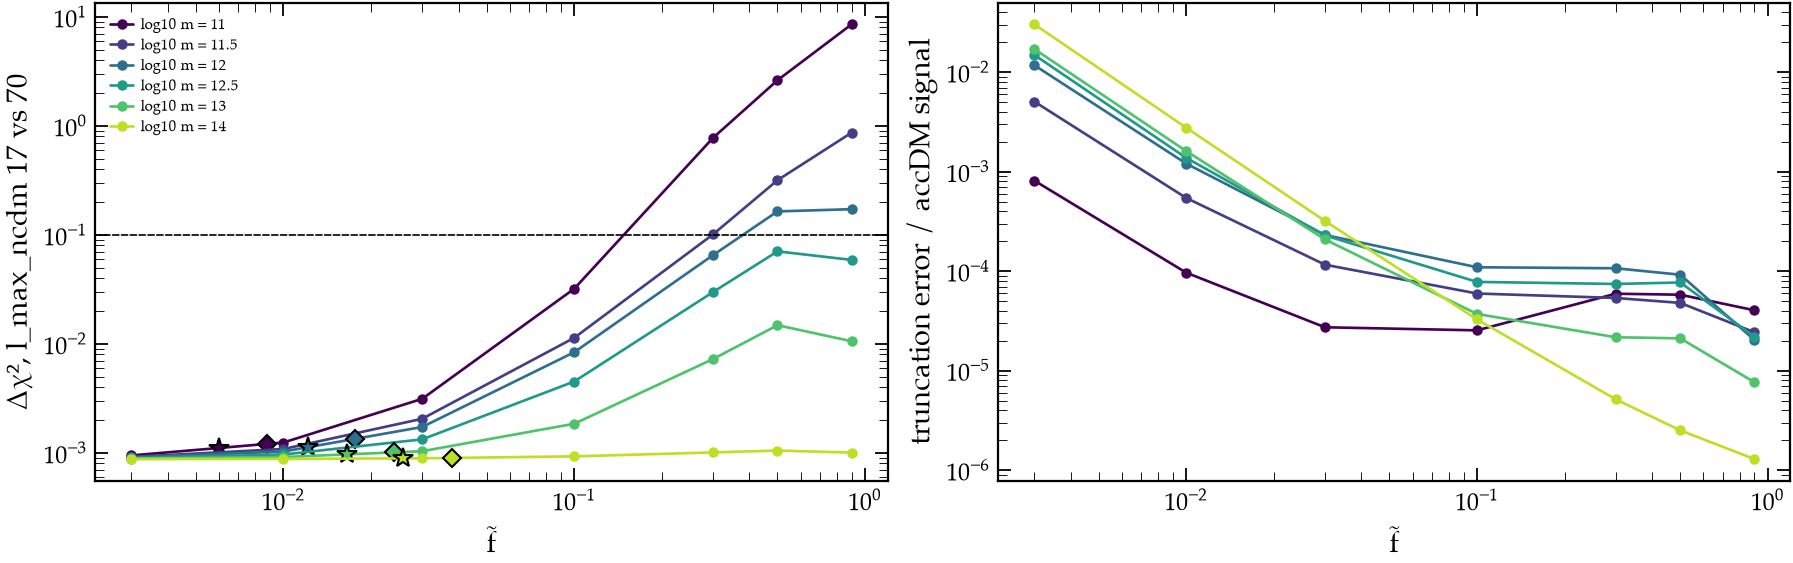

,chain 95%,chain 99%,Δχ² 17 at 99%,f̃ > 0.1 at 17,box share at 17,f̃ > 0.1 at 25,box share at 25,f̃ > 0.1 at 35,box share at 35,f̃ > 0.1 at 50,box share at 50
log10 m,,,,,,,,,,,
11.0,0.00602,0.00878,0.00121,0.148,0.852,0.2,0.8,0.282,0.718,-,0
11.5,-,-,-,0.298,0.701,0.409,0.59,-,0,-,0
12.0,0.0121,0.0177,0.00135,0.38,0.62,-,0,-,0,-,0
12.5,-,-,-,-,0,-,0,-,0,-,0
13.0,0.0166,0.024,0.00101,-,0,-,0,-,0,-,0
14.0,0.0257,0.0379,0.0009,-,0,-,0,-,0,-,0


In [3]:
f = np.array(F_GRID)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
for c, lm in zip(plt.cm.viridis(np.linspace(0, 0.9, len(MASSES))), MASSES):
    d17 = np.array([table.loc[(lm, ft), 'Δχ² 17'] for ft in F_GRID])
    axes[0].loglog(f, d17, 'o-', color=c, ms=4, label='log10 m = {:g}'.format(lm))
    axes[1].loglog(f, d17/np.array([table.loc[(lm, ft), 'signal'] for ft in F_GRID]), 'o-', color=c, ms=4)
    for q, marker in zip(QUANT.get(lm, []), ('*', 'D')):
        axes[0].plot(q, np.exp(np.interp(np.log(q), np.log(f), np.log(d17))), marker, color=c, ms=10 if marker == '*' else 6, mec='k')
axes[0].axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
axes[0].set_ylabel('Δχ², l_max_ncdm 17 vs 70')
axes[1].set_ylabel('truncation error / accDM signal')
for ax in axes:
    ax.set_xlabel('f̃')
axes[0].legend(fontsize=7)
plt.show()


def crossing(lm, L):
    """Smallest f̃ (log-log interpolated) where Δχ² of l_max L exceeds the tolerance."""
    d = np.array([table.loc[(lm, ft), 'Δχ² {}'.format(L)] for ft in F_GRID])
    above = np.nonzero(d > DCHI2_TOL)[0]
    if not len(above):
        return np.nan
    i = above[0]
    if i == 0:
        return F_GRID[0]
    return float(np.exp(np.interp(np.log(DCHI2_TOL), np.log([max(d[i - 1], 1e-12), d[i]]), np.log(F_GRID[i - 1:i + 1]))))


rows = []
for lm in MASSES:
    row = {'log10 m': lm}
    if lm in QUANT:
        d17 = np.array([table.loc[(lm, ft), 'Δχ² 17'] for ft in F_GRID])
        row.update({'chain 95%': QUANT[lm][0], 'chain 99%': QUANT[lm][1],
                    'Δχ² 17 at 99%': np.exp(np.interp(np.log(QUANT[lm][1]), np.log(f), np.log(d17)))})
    for L in LMAXS:
        fc = crossing(lm, L)
        row['f̃ > 0.1 at {}'.format(L)] = fc
        row['box share at {}'.format(L)] = 0.0 if np.isnan(fc) else (0.999 - fc)/0.999
    rows.append(row)
show(pd.DataFrame(rows).set_index('log10 m'), default='{:.3g}')

## 3. Where the error sits

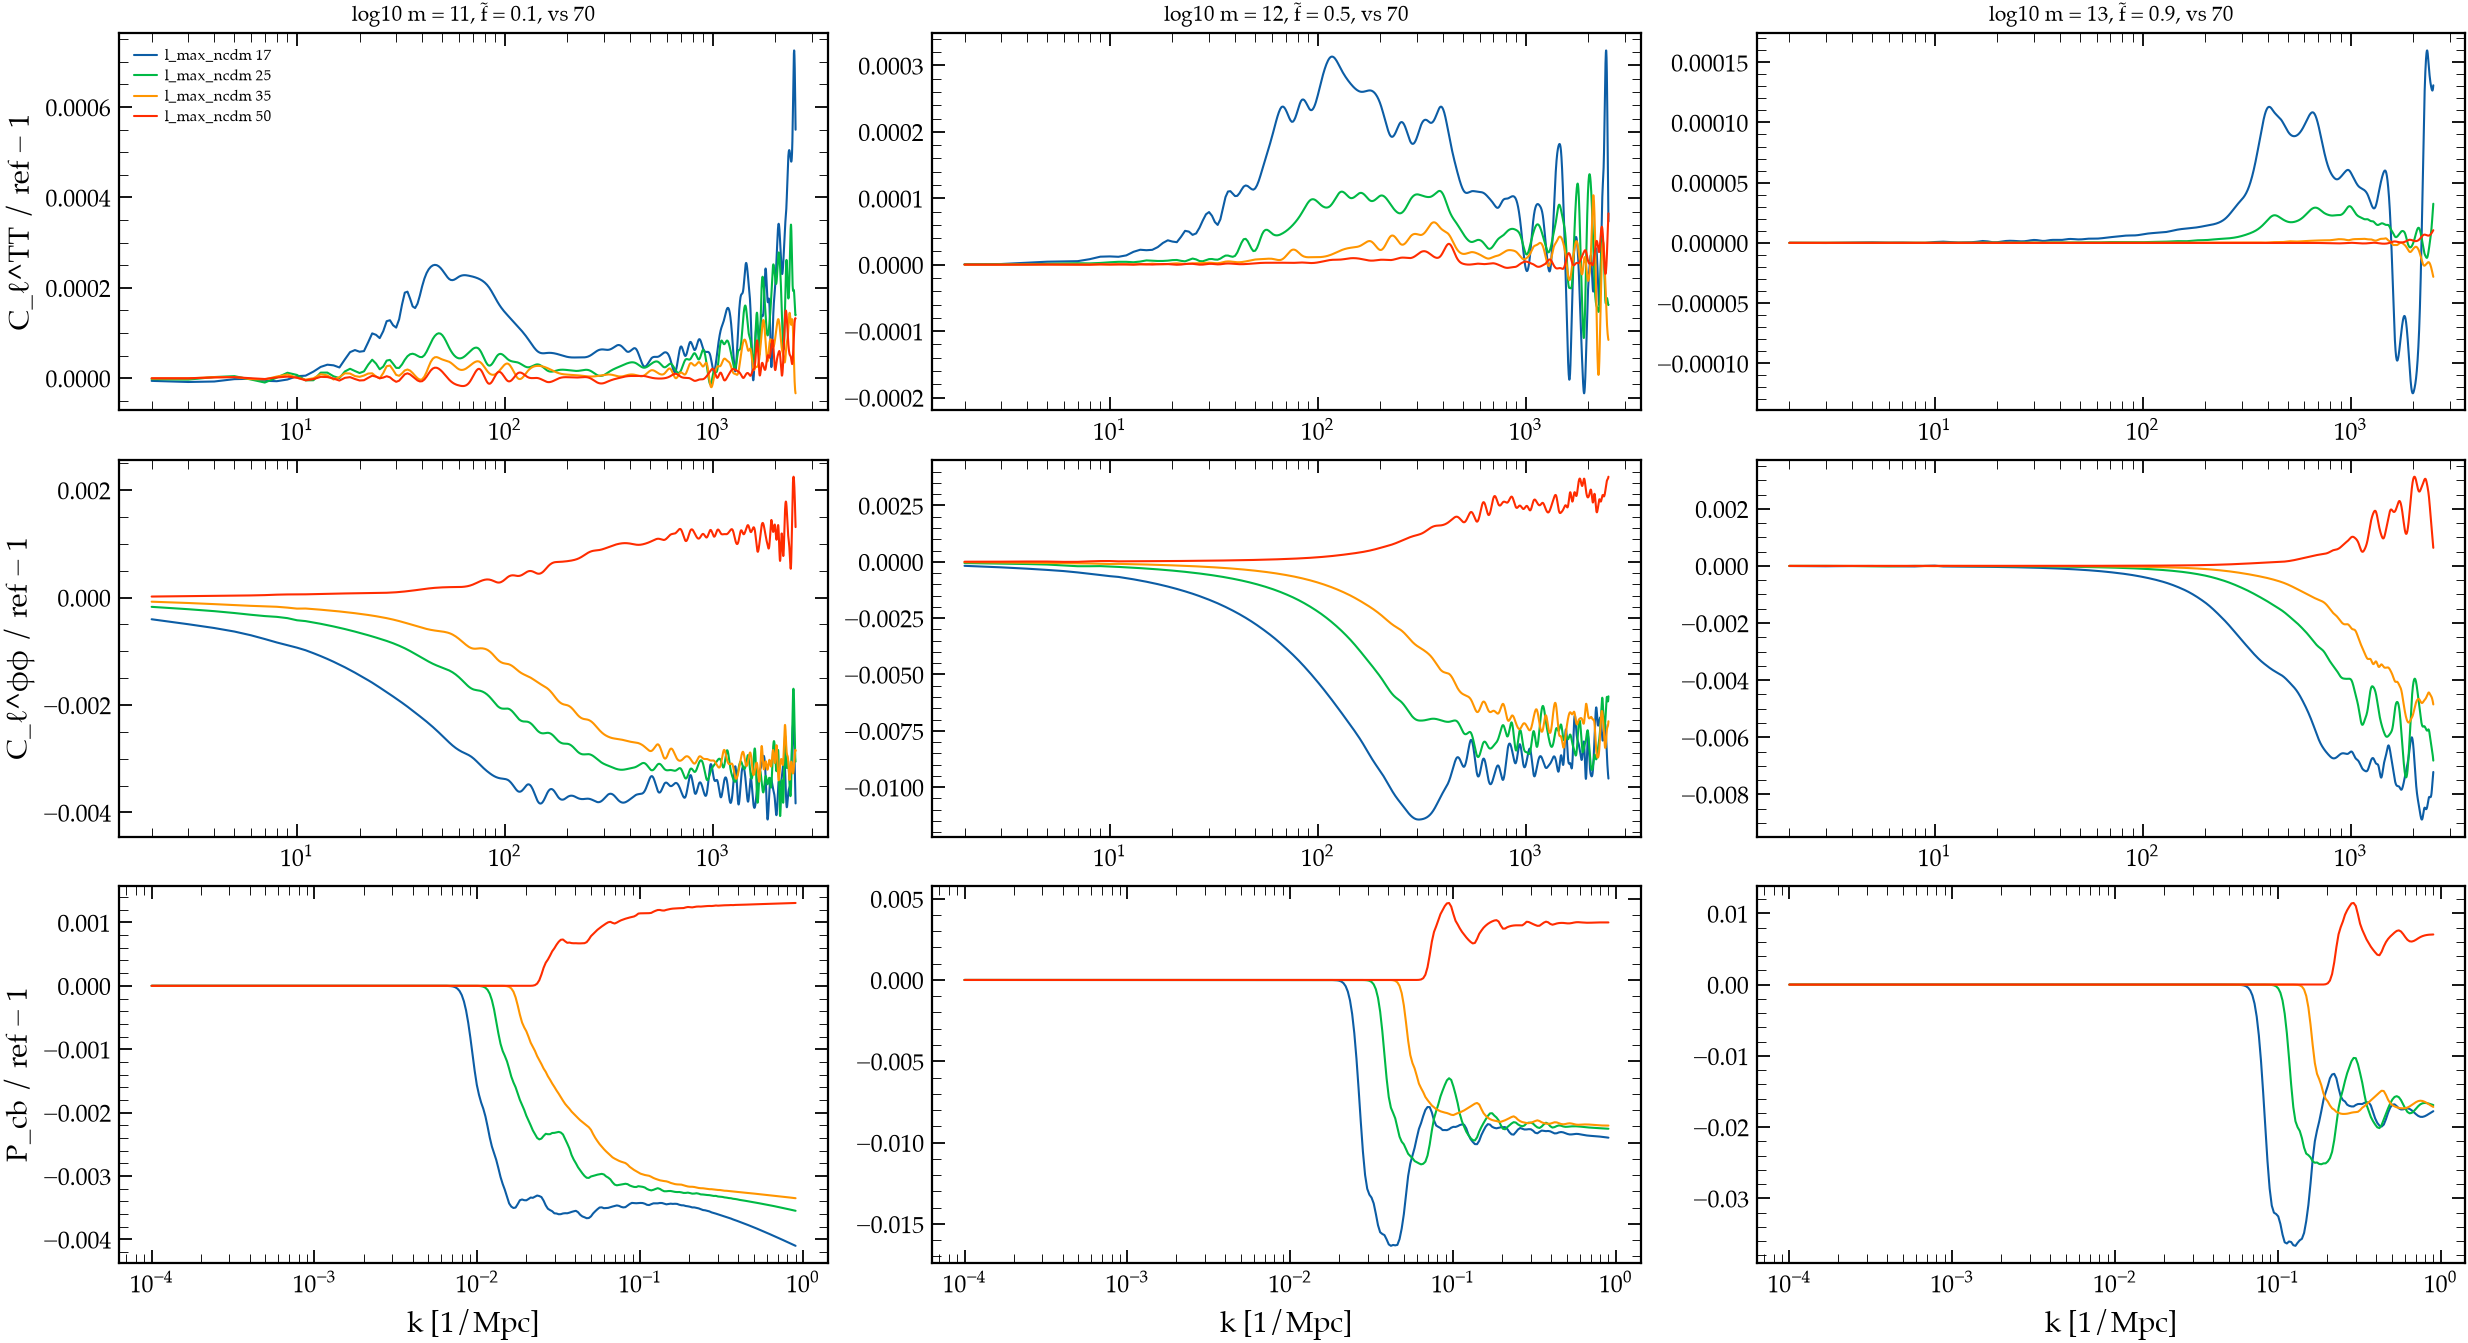

In [4]:
SHOW = [(11, 0.1), (12, 0.5), (13, 0.9)]
fig, axes = plt.subplots(3, len(SHOW), figsize=(5.5*len(SHOW), 9), constrained_layout=True)
for j, (lm, ft) in enumerate(SHOW):
    ref = res[(lm, ft, REF)]
    for L in LMAXS:
        out = res[(lm, ft, L)]
        axes[0, j].semilogx(ELL, out['tt']/ref['tt'] - 1, lw=1, label='l_max_ncdm {}'.format(L))
        axes[1, j].semilogx(ELL, out['pp']/ref['pp'] - 1, lw=1)
        axes[2, j].semilogx(KK, out['pk_cb']/ref['pk_cb'] - 1, lw=1)
    axes[0, j].set_title('log10 m = {:g}, f̃ = {:g}, vs 70'.format(lm, ft), fontsize=10)
    axes[2, j].set_xlabel('k [1/Mpc]')
axes[0, 0].set_ylabel('C_ℓ^TT / ref − 1')
axes[1, 0].set_ylabel('C_ℓ^φφ / ref − 1')
axes[2, 0].set_ylabel('P_cb / ref − 1')
axes[0, 0].legend(fontsize=7)
plt.show()

## 4. Separate from the momentum grid?

At three points, 200 bins/decade at `l_max_ncdm` = 17 and 70. If the errors are independent, the l_max
error is the same at 50 and 200 bins/decade, and the grid error the same at either l_max.

In [5]:
POINTS = [(11, 0.1), (11, 0.5), (12, 0.5)]
g = dict(zip([(lm, ft, L) for lm, ft in POINTS for L in (17, REF)],
             cache.many([params(lm, ft, l_max_ncdm=L, accdm_q_bins_per_decade=200) for lm, ft in POINTS for L in (17, REF)])))
rows = []
for lm, ft in POINTS:
    r = {(17, 50): res[(lm, ft, 17)], (REF, 50): res[(lm, ft, REF)], (17, 200): g[(lm, ft, 17)], (REF, 200): g[(lm, ft, REF)]}
    for label, a, b in [('l_max 17 vs 70, at 50/dec', (17, 50), (REF, 50)), ('l_max 17 vs 70, at 200/dec', (17, 200), (REF, 200)),
                        ('grid 50 vs 200, at l_max 17', (17, 50), (17, 200)), ('grid 50 vs 200, at l_max 70', (REF, 50), (REF, 200)),
                        ('both: (50, 17) vs (200, 70)', (17, 50), (REF, 200))]:
        c = compare(r[a], r[b])
        rows.append({'point': '{:g}, {:g}'.format(lm, ft), 'comparison': label, 'Δχ²': c['total'], 'lens': c['lens'],
                     'max ΔP_cb': c['dpk'], 'Δσ8_cb': c['dsigma8']})
show(pd.DataFrame(rows).set_index(['point', 'comparison']), {'Δσ8_cb': '{:+.1e}'}, default='{:.2e}')

Δχ²      lens max ΔP_cb    Δσ8_cb
point   comparison                                                         
11, 0.1 l_max 17 vs 70, at 50/dec    3.21e-02  2.16e-02  4.10e-03  -1.7e-03
        l_max 17 vs 70, at 200/dec   2.62e-02  2.16e-02  4.10e-03  -1.7e-03
        grid 50 vs 200, at l_max 17  3.22e-02  2.52e-05  3.37e-04  -1.2e-04
        grid 50 vs 200, at l_max 70  5.41e-03  2.34e-05  3.38e-04  -1.2e-04
        both: (50, 17) vs (200, 70)  5.05e-02  2.31e-02  4.34e-03  -1.9e-03
11, 0.5 l_max 17 vs 70, at 50/dec    2.62e+00  3.78e-01  2.47e-02  -1.1e-02
        l_max 17 vs 70, at 200/dec   4.83e-01  3.74e-01  2.47e-02  -1.1e-02
        grid 50 vs 200, at l_max 17  5.74e+00  1.84e-03  3.81e-03  -1.8e-03
        grid 50 vs 200, at l_max 70  1.11e+00  1.54e-03  3.77e-03  -1.8e-03
        both: (50, 17) vs (200, 70)  6.56e+00  4.27e-01  2.84e-02  -1.3e-02
12, 0.5 l_max 17 vs 70, at 50/dec    1.64e-01  1.54e-01  1.64e-02  -4.8e-03
        l_max 17 vs 70, at 200/dec   1.64e-01  1.54e-01  1.63e-02  -4.8e-03
        grid 50 vs 200, at l_max 17  3.77e-02  1.88e-04  1.69e-03  -7.7e-04
        grid 50 vs 200, at l_max 70  3.24e-02  1.85e-04  1.69e-03  -7.7e-04
        both: (50, 17) vs (200, 70)  2.20e-01  1.65e-01  1.79e-02  -5.6e-03